In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path
import torch

import numpy as np
import seaborn as sns
import os
#from analysis.utils import load_sweep_metadata, load_data, compute_success, chunk_data
from analysis.utils_decoding import evaluate_lags_leave_k_out

from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

from tdmpc2 import TDMPC2

In [7]:
from envs import make_env

## Initialize TDMPC2 agents

In [9]:
# Base configuration for state-based environment
CKPT_TO_USE = 500_000
CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'
CKPT_PATH_RGB = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

override_cfg_rgb = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_RGB,
    obs='rgb',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create RGB-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_rgb = compose(config_name="config")
    OmegaConf.set_struct(cfg_rgb, False)
    cfg_rgb = OmegaConf.merge(cfg_rgb, override_cfg_rgb)

cfg_rgb = parse_cfg(cfg_rgb)
set_seed(cfg_rgb.seed)

cfg_rgb.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_rgb = make_env(cfg_rgb)

print("\nLoading RGB-based agent...")
agent_rgb = TDMPC2(cfg_rgb)
if hasattr(cfg_rgb, 'checkpoint') and cfg_rgb.checkpoint:
    print(f"Loading checkpoint: {cfg_rgb.checkpoint}")
    agent_rgb.load(cfg_rgb.checkpoint)

# Create state-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = TDMPC2(cfg_state)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


## Create data

In [10]:
def wrap_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def state_to_x_th(obs_vec):
    """
    obs_vec: [x, cos(th), sin(th), dx, dth]
    returns x, dx, th, dth
    """
    x = float(obs_vec[0])
    cth = float(obs_vec[1])
    sth = float(obs_vec[2])
    dx = float(obs_vec[3])
    dth = float(obs_vec[4])
    th = np.arctan2(sth, cth)
    th = wrap_pi(th)
    return x, dx, th, dth


class OUNoise:

    def __init__(self, theta=0.15, sigma=0.4, mu=0.0, dt=1.0, rng=None):
        self.theta = float(theta)
        self.sigma = float(sigma)
        self.mu = float(mu)
        self.dt = float(dt)
        self.rng = np.random.default_rng() if rng is None else rng
        self.x = 0.0

    def reset(self):
        self.x = 0.0

    def sample(self):
        self.x += self.theta * (self.mu - self.x) * self.dt
        self.x += self.sigma * np.sqrt(self.dt) * float(
            self.rng.standard_normal())
        return self.x


def energy_shaping_u(obs_vec, kE=1.5, kx=0.15, kdx=0.05):
    """
    Heuristic swing-up: pump energy using th, dth; keep cart bounded via x, dx terms.
    """
    x, dx, th, dth = state_to_x_th(obs_vec)

    # energy proxy (dimensionless-ish): 0.5*dth^2 + (1 - cos(th))
    E = 0.5 * (dth**2) + (1.0 - np.cos(th))
    E_des = 2.0

    pump_dir = np.sign(dth * np.cos(th) + 1e-6)
    u = kE * (E_des - E) * pump_dir
    u += -kx * x - kdx * dx
    return float(u)


def pd_upright_u(obs_vec, kp_th=5.0, kd_th=0.8, kp_x=0.2, kd_x=0.1):
    """
    Simple PD around upright th~0 plus small cart centering.
    """
    x, dx, th, dth = state_to_x_th(obs_vec)
    u = -kp_th * th - kd_th * dth - kp_x * x - kd_x * dx
    return float(u)


class DMatchPolicy:
    """
    Episode-level mixture:
      A) OU noise
      B) Kick then OU
      C) Swing-up -> stabilize -> small OU (re-swing if not upright)
    obs_vec must be [x, cos(th), sin(th), dx, dth].
    """

    def __init__(
            self,
            action_low=-1.0,
            action_high=1.0,
            p_mode=(0.50, 0.5),
            ou_theta=0.15,
            ou_sigma_A=0.40,
            ou_sigma_B=0.25,
            ou_sigma_C=0.15,
            kick_steps=(10, 20),
            kick_flip_prob=0.25,
            swingup_steps=(100, 200),
            stabilize_steps=(50, 100),
            upright_theta_thresh=0.35,  # rad
            upright_dtheta_thresh=2.0,  # rad/s
            action_smooth=0.90,  # low-pass; closer to 1 => smoother
            rng=None):
        self.low = float(action_low)
        self.high = float(action_high)
        self.rng = np.random.default_rng() if rng is None else rng

        p = np.asarray(p_mode, dtype=np.float64)
        self.p_mode = p / p.sum()

        self.ou_A = OUNoise(theta=ou_theta, sigma=ou_sigma_A, rng=self.rng)
        self.ou_B = OUNoise(theta=ou_theta, sigma=ou_sigma_B, rng=self.rng)
        self.ou_C = OUNoise(theta=ou_theta, sigma=ou_sigma_C, rng=self.rng)

        self.kick_steps = kick_steps
        self.kick_flip_prob = float(kick_flip_prob)
        self.swingup_steps = swingup_steps
        self.stabilize_steps = stabilize_steps
        self.upright_theta_thresh = float(upright_theta_thresh)
        self.upright_dtheta_thresh = float(upright_dtheta_thresh)

        self.alpha = float(action_smooth)
        self.a_prev = 0.0

        self.mode = None
        self.t = 0
        self.kick_len = 0
        self.kick_sign = 1.0
        self.kick_flip_t = None
        self.swing_len = 0
        self.stab_len = 0

    def reset_episode(self, mode=None):
        self.t = 0
        if mode is None:
            self.mode = int(self.rng.choice([0, 1], p=self.p_mode))
        else:
            self.mode = mode
        self.a_prev = 0.0
        self.ou_A.reset()
        self.ou_B.reset()
        self.ou_C.reset()

        if self.mode == 1:
            self.kick_len = int(
                self.rng.integers(self.kick_steps[0], self.kick_steps[1] + 1))
            self.kick_sign = float(self.rng.choice([-1.0, 1.0]))
            self.kick_flip_t = int(self.rng.integers(1, self.kick_len)) if (
                self.rng.random() < self.kick_flip_prob) else None

        if self.mode == 2:
            self.swing_len = int(
                self.rng.integers(self.swingup_steps[0],
                                  self.swingup_steps[1] + 1))
            self.stab_len = int(
                self.rng.integers(self.stabilize_steps[0],
                                  self.stabilize_steps[1] + 1))

    def act(self, obs_vec):
        if self.mode == 0:
            a = self.ou_A.sample()

        elif self.mode == 1:
            if self.t < self.kick_len:
                sgn = self.kick_sign
                if self.kick_flip_t is not None and self.t >= self.kick_flip_t:
                    sgn = -sgn
                a = sgn
            else:
                a = self.ou_B.sample()

        else:
            # Swing-up -> stabilize -> small OU; re-swing if drifted away
            if self.t < self.swing_len:
                a = energy_shaping_u(obs_vec)
            elif self.t < self.swing_len + self.stab_len:
                a = pd_upright_u(obs_vec)
            else:
                x, dx, th, dth = state_to_x_th(obs_vec)
                if (abs(th) > self.upright_theta_thresh) or (
                        abs(dth) > self.upright_dtheta_thresh):
                    a = energy_shaping_u(obs_vec)
                else:
                    a = self.ou_C.sample()

        # --- ADD CART CENTERING HERE ---
        x, dx, _, _ = state_to_x_th(obs_vec)
        kx, kdx = 0.3, 0.25  # start here; tune
        a = float(a) - kx * x - kdx * dx

        # Low-pass filter + clip
        a = self.alpha * self.a_prev + (1.0 - self.alpha) * float(a)
        self.a_prev = a
        a = float(np.clip(a, self.low, self.high))

        self.t += 1
        return np.array([a], dtype=np.float32)


In [19]:
def collect_dmatch_simple(
    env,
    n_episodes=100,
    max_steps=500,
    seed=0,
    initial_states=[{
        'qpos': {
            'slider': 0.0,
            'hinge_1': 0.0
        },
        'qvel': {
            'slider': 0.0,
            'hinge_1': 0.0
        }
    }],
    n_episodes_per_initial_state=1,
    is_rgb=False,
):

    rng = np.random.default_rng(seed)
    policy = DMatchPolicy(
        rng=rng,
        ou_theta=0.05,
        ou_sigma_A=0.20,
        ou_sigma_B=0.25,
        ou_sigma_C=0.15,
        kick_steps=(10, 20),
        kick_flip_prob=0.25,
        action_smooth=0.95,
    )

    episodes = []  # list of episodes; each episode is list of transitions
    for initial_state in tqdm(initial_states):
        for ep in range(n_episodes_per_initial_state):

            if is_rgb:
                obs_pixel = env.reset(initial_state=initial_state)
                obs = env.get_state_obs()
            else:
                obs = env.reset(initial_state=initial_state)

            policy.reset_episode()

            ep_transitions = []
            for t in range(max_steps):
                act = policy.act(obs)  # behavior action
                act = torch.from_numpy(act)
                if is_rgb:
                    obs_next_pixel, reward, done, info = env.step(act)
                    obs_next = env.get_state_obs()
                else:
                    obs_next_pixel = None
                    obs_next, reward, done, info = env.step(act)

                ep_transitions.append({
                    # "obs": obs,  # s_t
                    "action": act.numpy(),  # a_t
                    "reward": float(reward) if reward is not None else 0.0,
                    "obs_next": obs_next,  # s_{t+1}
                    "obs_next_pixel": obs_next_pixel,  # s_{t+1}
                })

                if done:
                    break

            episodes.append(ep_transitions)

    return episodes

In [20]:
#Example usage:

initial_positions = [-1, 0, 1]
initial_angles = np.radians(np.linspace(0, 360, 5))

initial_states = []
for initial_position in initial_positions:
    for initial_angle in initial_angles:
        initial_states.append(
            {
                'qpos': {
                    'slider': initial_position,
                    'hinge_1': initial_angle,
                },
                'qvel': {
                    'slider': 0.0,
                    'hinge_1': 0.0
                }
            },)

episodes = collect_dmatch_simple(env_rgb,
                                 n_episodes=10,
                                 max_steps=500,
                                 seed=1,
                                 initial_states=initial_states,
                                 n_episodes_per_initial_state=1,
                                 is_rgb=True)
print(len(episodes), len(episodes[0]), episodes[0][0]["obs_next"])


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [01:14<00:00,  4.96s/it]

15 500 tensor([-9.9987e-01,  1.0000e+00, -1.8388e-04,  1.2654e-02, -1.8397e-02])


In [22]:
obs_episodes = []
rewards_episodes = []
actions_episodes = []
obs_episodes_pixel = []
for j in range(len(episodes)):
    obs_episode = np.array([episodes[j][i]['obs_next'] for i in range(500)])
    obs_episode_pixel = np.array(
        [episodes[j][i]['obs_next_pixel'] for i in range(500)])
    actions_episode = np.array([episodes[j][i]['action'] for i in range(500)])
    rewards_episode = np.array([episodes[j][i]['reward'] for i in range(500)])
    obs_episodes.append(obs_episode)
    obs_episodes_pixel.append(obs_episode_pixel)
    rewards_episodes.append(rewards_episode)
    actions_episodes.append(actions_episode)

obs_episodes_stacked = np.concatenate(obs_episodes, axis=0)
obs_episodes_pixel_stacked = np.concatenate(obs_episodes_pixel, axis=0)

In [23]:
obs_episodes_stacked.shape, obs_episodes_pixel_stacked.shape

((7500, 5), (7500, 9, 64, 64))

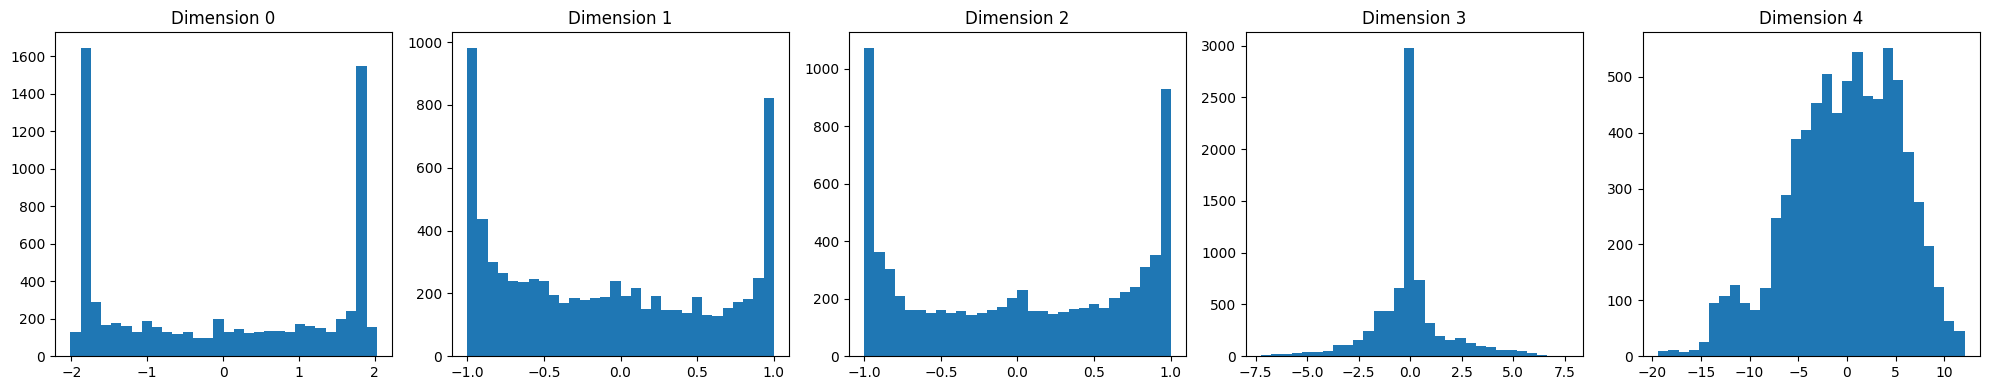

In [24]:
n_dims = obs_episodes_stacked.shape[1]
fig, axes = plt.subplots(1, n_dims, figsize=(4 * n_dims, 4))
for i in range(n_dims):
    axes[i].hist(obs_episodes_stacked[:, i], bins=30)
    axes[i].set_title(f'Dimension {i}')
plt.tight_layout()
plt.show()

## Convert observations to activations

In [25]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

## tdmpc2 state

In [28]:
zs_tdmpc2_state = []
for ep in obs_episodes:
    with torch.no_grad():
        x = torch.from_numpy(ep).cuda()
        z = agent_state.model.encode(x, task=None).detach().cpu().numpy()
        zs_tdmpc2_state.append(z)

zs_tdmpc2_state_all = np.concatenate(zs_tdmpc2_state, axis=0)

zs_tdmpc2_pixel = []
for ep in obs_episodes_pixel:
    with torch.no_grad():
        x = torch.from_numpy(ep).cuda()
        z = agent_rgb.model.encode(x, task=None).detach().cpu().numpy()
        zs_tdmpc2_pixel.append(z)

zs_tdmpc2_pixel_all = np.concatenate(zs_tdmpc2_pixel, axis=0)

In [29]:
zs_tdmpc2_pixel_all.shape, zs_tdmpc2_state_all.shape

((7500, 512), (7500, 512))

## Decoding

In [31]:
vars_all = {
    'z_tdmpc2_state':
        zs_tdmpc2_state,
    'z_tdmpc2_pixel':
        zs_tdmpc2_pixel,
    'obs': [obs_episode for obs_episode in obs_episodes],
    'position': [
        obs_episode[:, 0].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'cos(pole_angle)': [
        obs_episode[:, 1].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'sin(pole_angle)': [
        obs_episode[:, 2].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'cart_velocity': [
        obs_episode[:, 3].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'pole_angular_velocity': [
        obs_episode[:, 4].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'rewards': [
        rewards_episode.reshape(-1, 1) for rewards_episode in rewards_episodes
    ],
    'actions': [
        actions_episode.reshape(-1, 1) for actions_episode in actions_episodes
    ],
}

In [32]:
import os
import pickle

# Save vars_all to disk
save_path = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data'
os.makedirs(save_path, exist_ok=True)

with open(os.path.join(save_path, 'vars_all_pixel_vs_state.pkl'), 'wb') as f:
    pickle.dump(vars_all, f)

print(f"Saved vars_all to {save_path}")


Saved vars_all to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data


In [33]:
decoding_relationships = [
    #('z', 'obs'),
    #('obs', 'obs'),
    ('position', 'position'),
    ('cos(pole_angle)', 'cos(pole_angle)'),
    ('sin(pole_angle)', 'sin(pole_angle)'),
    ('cart_velocity', 'cart_velocity'),
    ('pole_angular_velocity', 'pole_angular_velocity'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
    ('z_tdmpc2_state', 'position'),
    ('z_tdmpc2_state', 'cos(pole_angle)'),
    ('z_tdmpc2_state', 'sin(pole_angle)'),
    ('z_tdmpc2_state', 'cart_velocity'),
    ('z_tdmpc2_state', 'pole_angular_velocity'),
    ('z_tdmpc2_state', 'rewards'),
    ('z_tdmpc2_state', 'actions'),
    ('z_tdmpc2_pixel', 'position'),
    ('z_tdmpc2_pixel', 'cos(pole_angle)'),
    ('z_tdmpc2_pixel', 'sin(pole_angle)'),
    ('z_tdmpc2_pixel', 'cart_velocity'),
    ('z_tdmpc2_pixel', 'pole_angular_velocity'),
    ('z_tdmpc2_pixel', 'rewards'),
    ('z_tdmpc2_pixel', 'actions'),
]


In [34]:
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2'
#path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/analysis/'
#'sac': vars_sac,

for model in ['linear_regression', 'lasso']:
    for predict_type in [
            'future',
            'difference',
    ]:
        results_decoding = {}
        for x_var, y_var in decoding_relationships:
            print(f"Decoding {x_var} -> {y_var}")
            results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
                vars_all[x_var],
                vars_all[y_var],
                model=model,
                lags=np.arange(-80, 81, 10),
                k_holdout=1,
                add_bootstrap_ci=True,
                shuffle_X=False,
                shuffle_y=False,
                predict_difference=True
                if predict_type == 'difference' else False,
                standardize_X=True
            )  #NOTE: I'm standardizing the X data, but not the y data

        #Save results_decoding to pickle file
        with open(
                os.path.join(
                    path_to_save,
                    f'results_decoding_{predict_type}_{model}_passive_data_pixel_vs_state.pkl'
                ), 'wb') as f:
            pickle.dump(results_decoding, f)

Decoding position -> position


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 48.30it/s]


Decoding cos(pole_angle) -> cos(pole_angle)


100%|██████████| 15/15 [00:00<00:00, 50.12it/s]


...

  0%|          | 0/15 [00:00<?, ?it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.535e+03, tolerance: 1.808e+01
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.705e+03, tolerance: 2.100e+01
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might wan

Decoding z_tdmpc2_pixel -> rewards


  7%|▋         | 1/15 [00:14<03:16, 14.04s/it]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.301e-01, tolerance: 1.643e-01
  model = cd_fast.enet_coordinate_descent(
 13%|█▎        | 2/15 [00:26<02:52, 13.25s/it]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.971e-01, tolerance: 1.837e-01
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: Converg

Decoding z_tdmpc2_pixel -> actions


  0%|          | 0/15 [00:00<?, ?it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.366e-01, tolerance: 2.165e-01
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.224e-01, tolerance: 2.075e-01
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might wan